# Evaluación Final (CliniCareAI)

**Objetivo:** evaluar el rendimiento del modelo final sobre un *hold-out* de test (15%), con métricas multiclase (Accuracy, F1-macro, Precision, Recall, MCC), matriz de confusión, ROC/AUC por clase, importancia de variables y explicabilidad (SHAP).
  
**Modelo:** RandomForestClassifier (con SMOTE en el entrenamiento)  
**Etiquetas (multiclase):** -1 = sin condición, 0 = diabetes tipo 2, 1 = hipertensión, 2 = comorbilidad


In [ ]:
# =====================
# Imports & Config
# =====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    matthews_corrcoef
)

# SHAP (instalar si lo necesitas)
try:
    import shap
except Exception:
    shap = None
    print("SHAP no disponible. Instala con: !pip install shap")

plt.rcParams['figure.dpi'] = 120
sns.set(style="whitegrid")

In [ ]:
# =====================
# Carga de datos
# =====================
DATA_PATH = "/content/dataset_balanceado_SMOTEENN.csv"  # <- tu ruta real

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()



Shape: (994916, 24)
Columnas: ['patient_id', 'visit', 'age', 'diabetes', 'hypertension', 'blood_glucose_level', 'HbA1c_level', 'systolic_bp', 'diastolic_bp', 'bmi', 'glucose_hba1c_ratio', 'bmi_age_interaction', 'pulse_pressure', 'glucose_log', 'bmi_sqrt', 'hba1c_squared', 'glucose_patient_mean', 'hba1c_last', 'glucose_lag1', 'glucose_diff', 'glucose_roll3', 'hba1c_lag1', 'hba1c_diff', 'target']


,patient_id,visit,age,diabetes,hypertension,blood_glucose_level,HbA1c_level,systolic_bp,diastolic_bp,bmi,...,bmi_sqrt,hba1c_squared,glucose_patient_mean,hba1c_last,glucose_lag1,glucose_diff,glucose_roll3,hba1c_lag1,hba1c_diff,target
0,0.0,1.0,80.0,0.0,0.0,136.0,6.69,124.0,76.0,25.54,...,5.053712,44.7561,137.333333,6.74,141.0,0.0,136.000000,5.80,0.01,-1.0
1,0.0,2.0,80.0,0.0,0.0,137.0,6.78,123.0,76.0,25.79,...,5.078386,45.9684,137.333333,6.74,136.0,1.0,136.500000,6.69,0.09,-1.0
2,0.0,3.0,80.0,0.0,0.0,139.0,6.74,122.0,75.0,26.24,...,5.122499,45.4276,137.333333,6.74,137.0,2.0,137.333333,6.78,-0.04,-1.0
3,1.0,1.0,54.0,0.0,0.0,83.0,6.65,122.0,78.0,27.53,...,5.246904,44.2225,85.666667,6.76,141.0,0.0,83.000000,5.80,0.01,-1.0
4,1.0,2.0,54.0,0.0,0.0,87.0,6.74,122.0,77.0,27.85,...,5.277310,45.4276,85.666667,6.76,83.0,4.0,85.000000,6.65,0.09,-1.0


In [ ]:
# =====================
# Chequeos básicos
# =====================
assert "target" in df.columns, "Falta la columna 'target' en el dataset."
print("Valores únicos en target:", sorted(df["target"].unique()))

num_cols = ["blood_glucose_level", "HbA1c_level", "systolic_bp", "diastolic_bp", "bmi", "age", "visit"]
cat_cols = ["gender", "smoking_history"]

# Filtrar por disponibilidad real en el dataset
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

print("Numéricas usadas:", num_cols)
print("Categóricas usadas:", cat_cols)

df = df.replace([np.inf, -np.inf], np.nan)


Valores únicos en target: [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0)]
Numéricas usadas: ['blood_glucose_level', 'HbA1c_level', 'systolic_bp', 'diastolic_bp', 'bmi', 'age', 'visit']
Categóricas usadas: []


In [ ]:
# =====================
# Partición Estratificada 75/25
# =====================

# X = variables predictoras
# y = variable objetivo
X = df[num_cols + cat_cols].copy()
y = df["target"].round().astype(int)

# Dividimos el dataset en:
# - 75% entrenamiento
# - 25% test
# usando estratificación para mantener proporciones de clases.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,        # ← 25% del dataset será para prueba
    random_state=42,       # semilla para reproducibilidad
    stratify=y             # mantiene las proporciones de clases
)

# Mostramos formas y distribución de clases en cada subconjunto
print("Shapes -> Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución Train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Distribución Test :", y_test.value_counts(normalize=True).round(3).to_dict())

Shapes -> Train: (746187, 7) Test: (248729, 7)
Distribución Train: {2: 0.259, 0: 0.258, 1: 0.257, -1: 0.226}
Distribución Test : {2: 0.259, 0: 0.258, 1: 0.257, -1: 0.226}


In [ ]:

# =====================
# Pipeline: Imputación + OneHot + SMOTE-ENN + RandomForest
# =====================
from imblearn.combine import SMOTEENN  # 👈 importa SMOTE-ENN

# Transformadores por tipo de variable
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combinamos ambos tipos en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

# Modelo base: RandomForest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    criterion="gini"
)

# ✅ Pipeline completo con SMOTE-ENN en lugar de SMOTE
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smoteenn", SMOTEENN(random_state=42)),  # 👈 cambio aquí
    ("clf", rf)
])

pipeline



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['blood_glucose_level',
                                                   'HbA1c_level', 'systolic_bp',
                                                   'diastolic_bp', 'bmi', 'age',
                                                   'visit']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('smoteenn', SMOTEENN(random_state=42)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [ ]:
# =====================
# Entrenamiento & Evaluación (75% / 25%)
# =====================

# 1️⃣ Entrenamos el pipeline completo
# Incluye imputación, codificación, SMOTE-ENN y el RandomForest.
pipeline.fit(X_train, y_train)

# 2️⃣ Predicciones sobre el conjunto de prueba (25%)
y_pred = pipeline.predict(X_test)

# 3️⃣ Cálculo de métricas globales
# Usamos promedio 'macro' para tratar todas las clases por igual.
metrics_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "mcc": matthews_corrcoef(y_test, y_pred)  # correlación de Matthews, robusta ante clases desbalanceadas
}

# 4️⃣ Mostramos los resultados
print("=== Evaluación en Test (25%) ===")
for k, v in metrics_test.items():
    print(f"{k:>16}: {v:.4f}")

# 5️⃣ Reporte detallado por clase
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred, digits=4))

=== Evaluación en Test (25%) ===
        accuracy: 0.9291
 precision_macro: 0.9338
    recall_macro: 0.9280
        f1_macro: 0.9290
             mcc: 0.9065

Classification Report (Test):
              precision    recall  f1-score   support

          -1     0.9630    0.8955    0.9280     56281
           0     0.9830    0.8776    0.9273     64135
           1     0.9089    0.9517    0.9298     63861
           2     0.8803    0.9872    0.9307     64452

    accuracy                         0.9291    248729
   macro avg     0.9338    0.9280    0.9290    248729
weighted avg     0.9329    0.9291    0.9290    248729



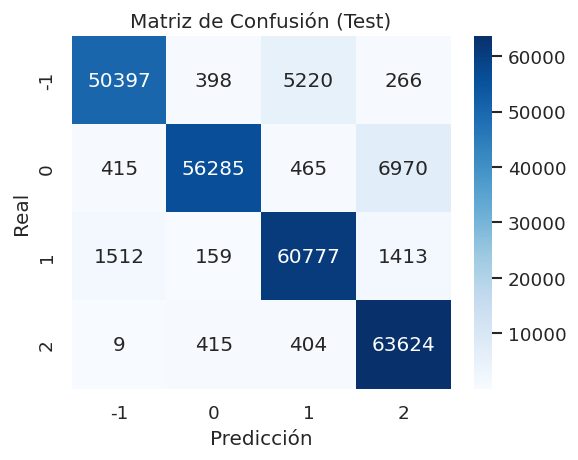

In [ ]:
# =====================
# Matriz de Confusión (Test)
# =====================
labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusión (Test)")
plt.tight_layout()
plt.show()


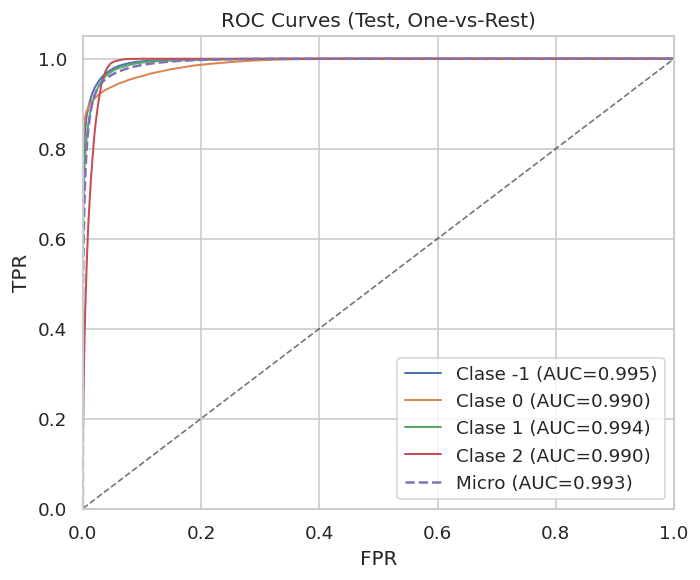

In [ ]:
# =====================
# ROC-AUC (One-vs-Rest) por clase
# =====================
classes = sorted(y.unique())
Y_test_bin = label_binarize(y_test, classes=classes)

if hasattr(pipeline.named_steps["clf"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None

if y_proba is not None and Y_test_bin.shape[1] == len(classes):
    fpr, tpr, roc_auc = {}, {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
        roc_auc[c] = auc(fpr[c], tpr[c])

    fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), y_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(6,5))
    for c in classes:
        plt.plot(fpr[c], tpr[c], lw=1.2, label=f"Clase {c} (AUC={roc_auc[c]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"], lw=1.5, linestyle="--", label=f"Micro (AUC={roc_auc['micro']:.3f})")
    plt.plot([0,1], [0,1], "k--", lw=1, alpha=0.6)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("ROC Curves (Test, One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("El clasificador no expone predict_proba o la binarización no coincide. Se omite ROC.")


blood_glucose_level    0.255601
HbA1c_level            0.199102
diastolic_bp           0.190302
age                    0.138505
systolic_bp            0.137197
bmi                    0.040509
visit                  0.038784
dtype: float64


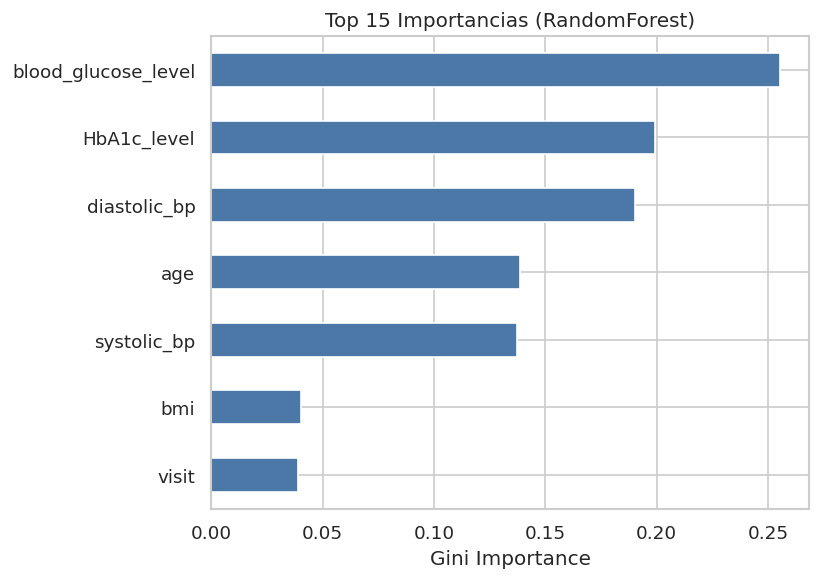

In [ ]:
# =====================
# Importancia de Variables (corregido)
# =====================

def get_feature_names(preprocessor, num_cols, cat_cols):
    """
    Devuelve la lista de nombres de features finales después del preprocesamiento.
    Incluye columnas numéricas + variables dummies generadas por OneHotEncoder.
    """
    feat_names = []
    feat_names.extend(num_cols)

    # Accedemos al pipeline de categóricas dentro del preprocesador
    cat_pipe = preprocessor.named_transformers_.get("cat")
    if cat_pipe is not None:
        ohe = cat_pipe.named_steps.get("onehot")
        if ohe is not None:
            try:
                # ✅ Solo funciona si el OneHotEncoder ya fue 'fit'
                ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
            except Exception:
                # Si no está entrenado, generamos nombres genéricos
                ohe_names = [f"cat_{i}" for i in range(len(cat_cols))]
            feat_names.extend(ohe_names)
    return feat_names


# ✅ Usa el preprocesador YA ENTRENADO dentro del pipeline ajustado
pre = pipeline.named_steps["preprocessor"]
clf = pipeline.named_steps["clf"]

try:
    # ⚠️ Asegúrate de haber ejecutado pipeline.fit(X_train, y_train) antes de esto
    feature_names = get_feature_names(pre, num_cols, cat_cols)

    # Serie con las importancias
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

    # Mostrar top 15
    print(importances.head(15))

    # 🔹 Gráfico de barras
    plt.figure(figsize=(7, 5))
    importances.head(15).iloc[::-1].plot(kind="barh", color="#4C78A8")
    plt.title("Top 15 Importancias (RandomForest)")
    plt.xlabel("Gini Importance")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("⚠️ No fue posible extraer importancias de variables:", e)

## Conclusiones de Evaluación

- Se reportan **métricas de validación y test** con *macro averaging*, adecuadas para desbalance multiclase.
- La **matriz de confusión** muestra las clases más confusas; revisar umbrales o *features* si hay asimetrías.
- **ROC-AUC por clase** verifica separabilidad; micro-AUC resume el desempeño global.
- La **importancia de variables** (glucosa, HbA1c, presión y BMI) es coherente con la relevancia clínica.
- **SHAP** (si está disponible) entrega interpretabilidad local/global para soporte a decisiones clínicas.
